/tmp/ipykernel_2575/991694695.py:50: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  data = data.fillna(method='bfill')


 Model Performance:
RMSE: 1.0421725571648648
R2 Score: 0.5578015351030692


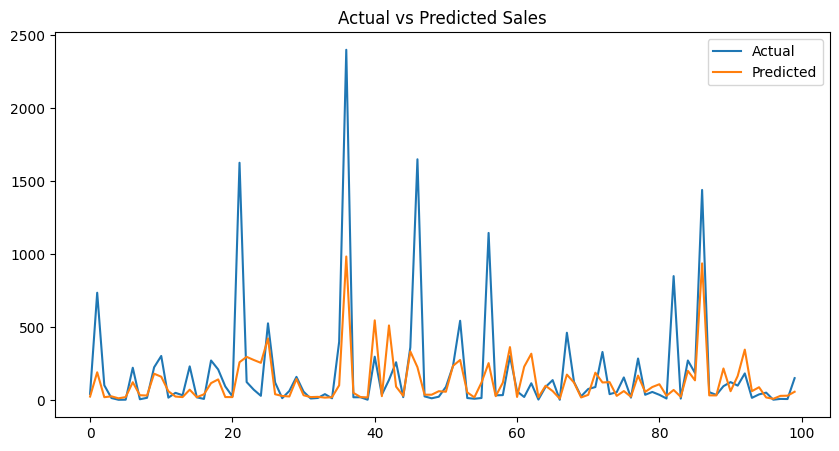

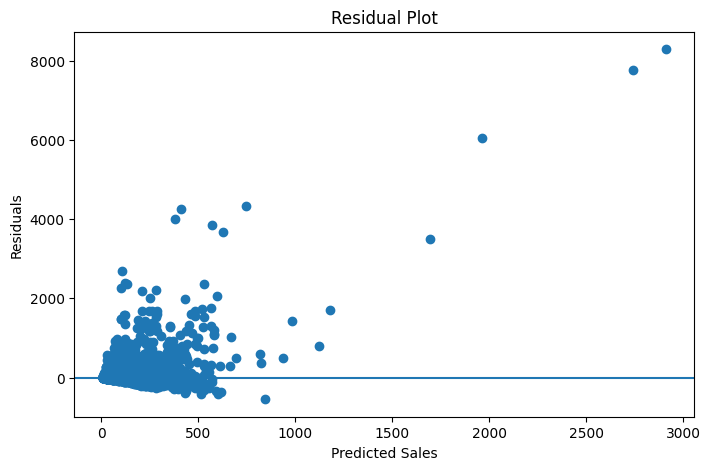

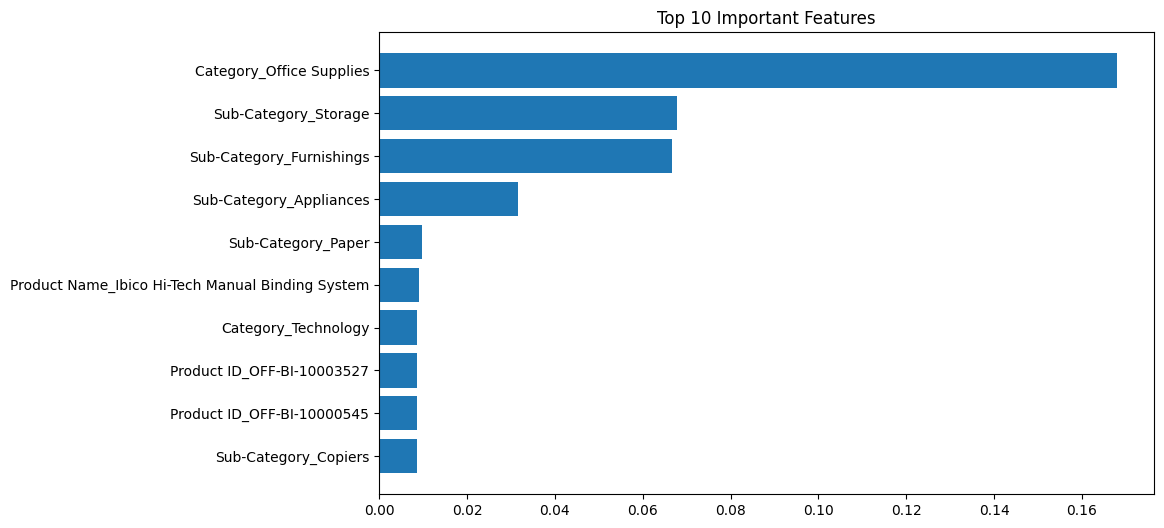

✅ Project Completed Successfully


In [2]:
# ==========================================
#  SALES FORECASTING USING MACHINE LEARNING
# ==========================================

#  1. IMPORT LIBRARIES
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import mean_squared_error, r2_score
from xgboost import XGBRegressor

#  2. LOAD DATA
data = pd.read_csv("train.csv")

# Clean column names
data.columns = data.columns.str.strip()

# Convert to datetime
data['Order Date'] = pd.to_datetime(data['Order Date'], dayfirst=True)

# Sort data
data = data.sort_values('Order Date')

#  3. FEATURE ENGINEERING

# Date features
data['Year'] = data['Order Date'].dt.year
data['Month'] = data['Order Date'].dt.month
data['Day'] = data['Order Date'].dt.day
data['DayOfWeek'] = data['Order Date'].dt.dayofweek
data['Quarter'] = data['Order Date'].dt.quarter

# Weekend feature
data['IsWeekend'] = data['DayOfWeek'].isin([5,6]).astype(int)

# Cyclical encoding
data['Month_sin'] = np.sin(2 * np.pi * data['Month'] / 12)
data['Month_cos'] = np.cos(2 * np.pi * data['Month'] / 12)

# Lag features
data['Sales_Lag1'] = data['Sales'].shift(1)
data['Sales_Lag7'] = data['Sales'].shift(7)

# Rolling features
data['Sales_Rolling_Mean_7'] = data['Sales'].rolling(7).mean()
data['Sales_Rolling_Mean_14'] = data['Sales'].rolling(14).mean()

#  4. HANDLE MISSING VALUES
data = data.fillna(method='bfill')

#  5. HANDLE OUTLIERS (LOG TRANSFORM)
data['Sales'] = np.log1p(data['Sales'])

#  6. ENCODE CATEGORICAL VARIABLES
data = pd.get_dummies(data, drop_first=True)

#  7. DROP UNNECESSARY COLUMNS
columns_to_drop = [
    'Row ID','Order ID','Customer Name','Product Name',
    'Ship Date','Customer ID','Country','City','State',
    'Postal Code','Product ID','Order Date'
]

data = data.drop(columns=[col for col in columns_to_drop if col in data.columns])

#  8. DEFINE FEATURES & TARGET
X = data.drop('Sales', axis=1)
y = data['Sales']

#  9. TRAIN-TEST SPLIT (TIME-BASED)
split_index = int(len(data) * 0.8)

X_train = X[:split_index]
X_test = X[split_index:]

y_train = y[:split_index]
y_test = y[split_index:]

#  10. TRAIN MODEL (XGBOOST)
model = XGBRegressor(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.05,
    random_state=42
)

model.fit(X_train, y_train)

#  11. PREDICTIONS
y_pred = model.predict(X_test)

#  12. EVALUATION
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(" Model Performance:")
print("RMSE:", rmse)
print("R2 Score:", r2)

#  13. CONVERT BACK TO ORIGINAL SCALE
y_test_actual = np.expm1(y_test)
y_pred_actual = np.expm1(y_pred)

#  14. VISUALIZATION

# Actual vs Predicted
plt.figure(figsize=(10,5))
plt.plot(y_test_actual.values[:100], label='Actual')
plt.plot(y_pred_actual[:100], label='Predicted')
plt.title("Actual vs Predicted Sales")
plt.legend()
plt.show()

# Residual Plot
residuals = y_test_actual - y_pred_actual

plt.figure(figsize=(8,5))
plt.scatter(y_pred_actual, residuals)
plt.axhline(y=0)
plt.title("Residual Plot")
plt.xlabel("Predicted Sales")
plt.ylabel("Residuals")
plt.show()

#  15. FEATURE IMPORTANCE
importance = model.feature_importances_

feat_imp = pd.DataFrame({
    'Feature': X.columns,
    'Importance': importance
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10,6))
plt.barh(feat_imp['Feature'][:10], feat_imp['Importance'][:10])
plt.gca().invert_yaxis()
plt.title("Top 10 Important Features")
plt.show()

print("✅ Project Completed Successfully")